In [ ]:
nom et prenom : toubouh loubna
master : génie logiciel pour le cloud
tp : J’ai implémenté et comparé des modèles des régression lineaire,multiple et polynomiale from scratch et avec la bibliothéque sklearn en utilisant la descente de gradient, puis évalué leurs performances avec MSE et des visualisations."

In [1]:
import os
os.getcwd()

'C:\\Users\\hil'

In [2]:
import pandas as pd

data = pd.read_csv("Food_Delivery_Times.csv")
print(data.head())


   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  


In [3]:
import pandas as pd

data = pd.read_csv("Food_Delivery_Times.csv")

data


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [4]:
x = data['Distance_km'].to_numpy()
y = data['Delivery_Time_min'].to_numpy()

print(x)
print(y)
print(x.shape)
print(y.shape)

[ 7.93 16.42  9.52  7.44 19.03 19.4   9.52 17.39  1.78 10.62 16.86 15.54
 10.89  4.69  2.8   2.17 17.86  2.53  6.58  5.38 15.56 13.08  0.86  5.83
 11.2  14.59 12.91 13.92  4.04 18.05 12.88 19.45  4.58 19.73  2.47 17.8
  5.96 12.85  1.02  6.84  8.68 10.69  0.99  1.11  2.16 13.17  8.79  5.93
  2.09  7.57 10.52  4.83 19.81 10.1   7.64 12.35  5.9   0.9  11.58 16.16
 15.51 12.16  4.96  3.64  2.85 10.4  12.31  3.53 15.56 13.6  15.23  4.17
  3.21  6.38 16.54 12.02 11.94  9.08  3.46  6.8  17.38  3.25 10.28 16.14
  3.55 10.65 19.03  7.3   7.03 12.43 12.76 11.39 19.41 13.17  8.32  1.92
  1.15 17.8   7.46  7.25 16.7  17.2   0.86 18.76  9.22  2.84 17.59 14.89
  1.3  18.99  1.6   8.26 10.16 12.03 14.73 12.56  5.53 10.18 15.5   2.98
 16.69 11.22  8.53 12.49  0.97 12.6   6.91 18.97  4.05 14.29  1.3  12.11
 14.94  2.29 17.36 18.48 16.25  5.13 15.81  0.61  5.55 19.35  4.03  7.09
  8.25 11.26 19.7   0.8   7.   14.43  6.89  5.13  1.5   2.78 11.31 15.05
  5.78 11.83  8.08 16.1   9.74 17.6  10.22  2.19 11.

In [5]:
#suppression du colonne inutile
data = data.drop(columns=["Order_ID"])


In [6]:
data


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...
995,8.50,Clear,High,Evening,Car,13,3.0,54
996,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [7]:
#transformer les variables texte en nombres
data = pd.get_dummies(data, drop_first=True) 
data = data.astype(float)
data = data.fillna(0)

In [8]:
data

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Weather_Foggy,Weather_Rainy,Weather_Snowy,Weather_Windy,Traffic_Level_Low,Traffic_Level_Medium,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Vehicle_Type_Car,Vehicle_Type_Scooter
0,7.93,12.0,1.0,43.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1,16.42,20.0,2.0,84.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
2,9.52,28.0,1.0,59.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,7.44,5.0,1.0,37.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
4,19.03,16.0,5.0,68.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,8.50,13.0,3.0,54.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
996,16.28,8.0,9.0,71.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
997,15.62,26.0,2.0,81.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
998,14.17,8.0,0.0,55.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


Iteration 0, J(a,b) = 443.27870067052646
Iteration 1000, J(a,b) = 95.57239685384091
Iteration 2000, J(a,b) = 94.90988690684573
Iteration 3000, J(a,b) = 94.9046001230503
Iteration 4000, J(a,b) = 94.90455793487935
Iteration 5000, J(a,b) = 94.90455759822065
Iteration 6000, J(a,b) = 94.90455759553413
Iteration 7000, J(a,b) = 94.90455759551268
Iteration 8000, J(a,b) = 94.90455759551253
Iteration 9000, J(a,b) = 94.90455759551254
a = 3.025871676500842
b = 26.29182171034628
Coût final J(a,b) = 94.90455759551253


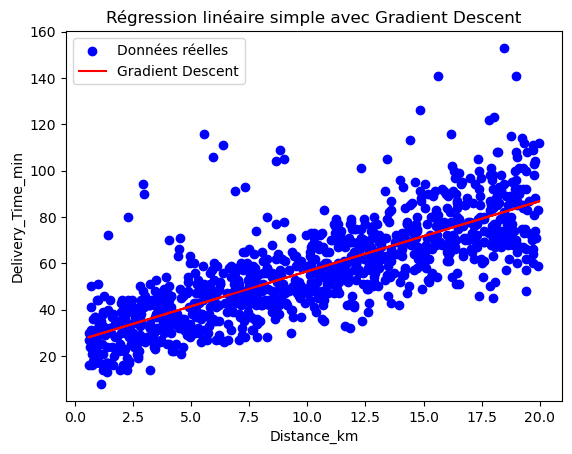

MSE : 189.80911519102506


In [9]:
# la Regression linéaire From scratch
import numpy as np
import matplotlib.pyplot as plt

#nombre de point dans la liste x
n = len(x)
#initialisation au hasard de a et b
a = np.random.randn()
b = np.random.randn()

def J(a, b, x, y):      #la fonction cout 
  return (1/(2*n)) * np.sum((y - (a*x + b))**2)
#initialisation de paramètres  Gradient Descent    
alpha = 0.01
iteration = 10000    

#Boucle Gradient Descent
for i in range(iteration):
    y_pred = a*x + b  #calcule de des predictions
    da = -(1/n) * np.sum(x * (y - y_pred))  #dérivée de a
    db = -(1/n) * np.sum(y - y_pred)  #dérivée de b 
    #mise a jour de a et b  
    a = a - alpha * da     
    b = b - alpha * db
    
    if i % 1000 == 0:    # l'affichage de coût tous les 1000 itérations
        print(f"Iteration {i}, J(a,b) = {J(a,b,x,y)}")

print("a =", a) #affichage de la pente final
print("b =", b) #affichage de l'ordonnée à l'origine
print("Coût final J(a,b) =", J(a,b,x,y)) #cout final

#Tracer la droite
plt.scatter(x, y, color='blue', label='Données réelles')  #la creation d'une nuage de points
plt.plot(x, a*x + b, color='red', label='Gradient Descent') #droite de regression
plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.title("Régression linéaire simple avec Gradient Descent")
plt.legend()

plt.show()   

y_pred = a*x + b  # recalcul des prédictions finales
mse = np.mean((y - y_pred)**2)  # MSE (Mean Squared Error)
print("MSE :", mse)





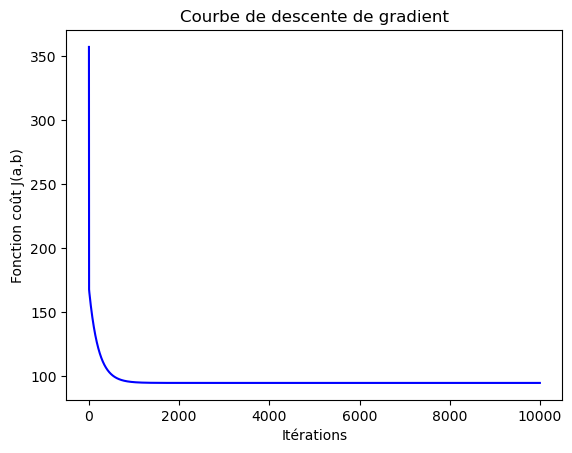

In [10]:
# Cette partie permet de tracer l'évolution de la fonction coût J(θ), montre le travail déjà effectué par l'algorithme
# en fonction du nombre d'itérations.
# Elle sert à analyser le comportement de la descente de gradient
# et à vérifier si l'algorithme converge correctement vers un minimum.
import numpy as np
import matplotlib.pyplot as plt

n = len(x)
# Initialisation aléatoire des paramètres a (pente) et b (intercept)
a = np.random.randn()
b = np.random.randn()

def J(a, b, x, y):
    return (1/(2*n)) * np.sum((y - (a*x + b))**2)

alpha = 0.01
iteration = 10000

J_history = []  # pour stocker l’évolution de la fonction coût

for i in range(iteration): # Boucle de descente de gradient
    y_pred = a*x + b
    da = -(1/n) * np.sum(x * (y - y_pred))
    db = -(1/n) * np.sum(y - y_pred)
    a = a - alpha * da
    b = b - alpha * db
    J_history.append(J(a, b, x, y))   # stockage de la valeur de la fonction coût

# Tracer la courbe de descente de gradient
plt.plot(range(iteration), J_history, color='blue')
plt.xlabel("Itérations")
plt.ylabel("Fonction coût J(a,b)")
plt.title("Courbe de descente de gradient")
plt.show()

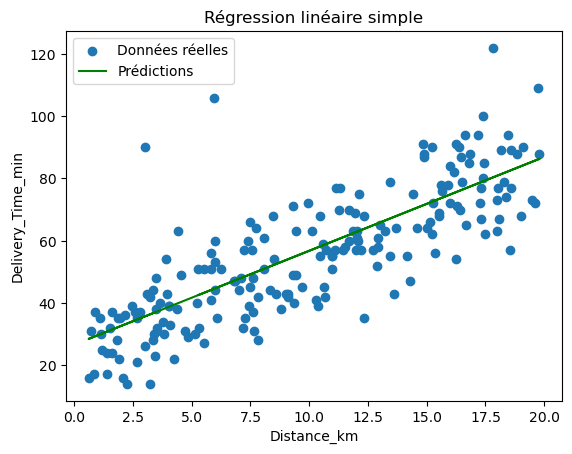

MSE: 158.16196727280166


In [11]:

#La régression linéaire simple avec sklearn

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

X = data[['Distance_km']]  
y = data['Delivery_Time_min']

# Séparer en training et test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()   # Cet objet va permettre de calculer automatiquement la droite de régression (y = a*x + b)
model.fit(X_train, y_train)    #calculer la meilleuredroite pour minimser l'erreur

y_pred = model.predict(X_test)  #calcule les valeurs prédites pour tous les poinrs x

plt.scatter(X_test, y_test, label="Données réelles")  #affichage les points réels
plt.plot(X_test, y_pred, color='green', label="Prédictions")  #tracer la droite
plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.title("Régression linéaire simple")
plt.legend()
plt.show()    #affichele graphe

# Calcul de la MSE
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)



Iteration 0, J = 1848.990088292194
Iteration 1000, J = 299.41385629894376
Iteration 2000, J = 88.85239163820158
Iteration 3000, J = 59.80000479282647
Iteration 4000, J = 55.621102608318246
Iteration 5000, J = 54.94584648134238
Iteration 6000, J = 54.804309021973026
Iteration 7000, J = 54.761751651865445
Iteration 8000, J = 54.74494174407677
Iteration 9000, J = 54.737413177558224
Theta = [56.72943723 17.0239465   6.94599485 -1.80833456  2.29270308  1.95394883
  2.73272564  0.59709973 -5.43900979 -2.67623844  0.10060446 -0.72178688
 -0.39281562  0.21698029 -0.45576804]
Erreur moyenne : 6.464301557639358


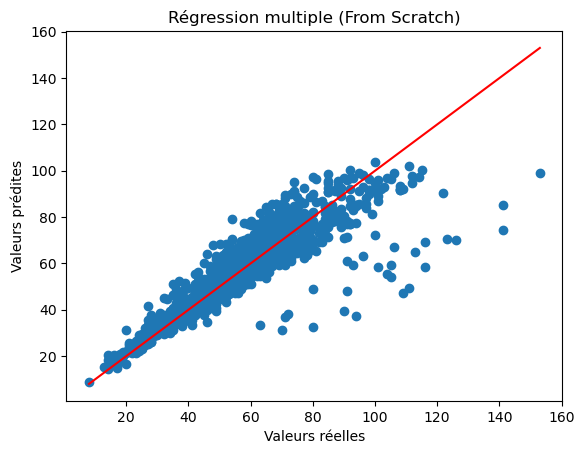

MSE: 109.46777741752851


In [12]:
#la Regression Multiple From scratch

X_multi = data.drop("Delivery_Time_min", axis=1).values   # Supprime la colonne "Delivery_Time_min" du Dataset pour prendre toutes les colonnes sauf la cible
y = data["Delivery_Time_min"].values     #la prediction de y

# normalisation FROM SCRATCH pour aide la descente de gradient à converger plus rapide 
mean = np.mean(X_multi, axis=0)  #calcule la moyenne de chaque feature
std = np.std(X_multi, axis=0)   #calcule de l'ecart type
std[std == 0] = 1   #evite la division par zero

X_multi = (X_multi - mean) / std  #calcule de la normalisation

m = len(y)                      #nombre de données
X_b = np.c_[np.ones((m,1)), X_multi]  # ajouter une colonne de 1 à gauche de X
n = X_b.shape[1]
theta = np.zeros(n)             #initialise theta a zero
def J(theta, X_b, y):             #fonction cout qui calcule l'erreur
    m = len(y)
    return (1/(2*m)) * np.sum((X_b.dot(theta) - y)**2)

alpha = 0.001                   # le pas
iterations = 10000            # nombre d’itérations de la descente de gradient

for i in range(iterations):    # descente de gradient
    y_pred = X_b.dot(theta)   # la valeur prédite par la droite actuelle
    gradient = (1/m) * X_b.T.dot(y_pred - y)
    theta = theta - alpha * gradient  # mettre a jour a theta
    
    if i % 1000 == 0:       # affichage de l'erreur toutes les 1000 itérations pour vérifier que ça diminue
         print(f"Iteration {i}, J =", J(theta, X_b, y))
print("Theta =", theta)    # affiche les coefficients appris

y_pred = X_b.dot(theta)   # les prédictions finales

print("Erreur moyenne :", np.mean(np.abs(y_pred - y)))


plt.scatter(y, y_pred)    # points réel vs prédit
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red')   #ligne rouge c'est le modèle parfait

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression multiple (From Scratch)")
plt.show()

# MSE : moyenne des carrés des erreurs
mse = np.mean((y_pred - y)**2)
print("MSE:", mse)


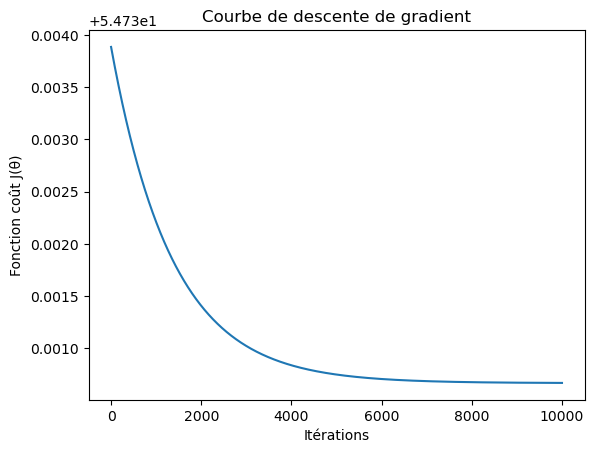

In [13]:
# Elle sert à vérifier que l’erreur diminue progressivement

J_history = []  # liste pour stocker la valeur de J à chaque itération

for i in range(iterations):
    y_pred = X_b.dot(theta)
    gradient = (1/m) * X_b.T.dot(y_pred - y)
    theta = theta - alpha * gradient
    J_history.append(J(theta, X_b, y))

   

plt.plot(J_history)
plt.xlabel("Itérations")
plt.ylabel("Fonction coût J(θ)")
plt.title("Courbe de descente de gradient")
plt.show()

Theta (intercept + coefficients) :
Intercept (b) : 17.39173960818885
Coefficients (a1, a2, ...) : [  2.99972593   0.96699042  -0.61603949   5.94077556   4.60735591
   9.06964925   1.39588995 -10.7425739   -5.14235548   0.30410863
  -1.71047298  -2.06370952   0.55734438  -0.96186007]
Erreur moyenne : 5.970762292603581


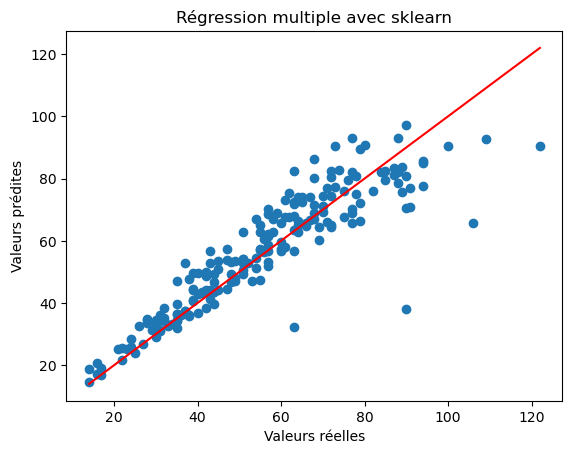

MSE : 78.79248568989706


In [14]:
#Regression lineaire avec sklearn

X = data.drop("Delivery_Time_min", axis=1)  # toutes les features sauf la cible
y = data["Delivery_Time_min"]               # la cible

# Séparer en train et test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()     # cration de modéle vide
model.fit(X_train, y_train)     # entraîne le modèle de régression linéaire sur les données X et y pour apprendre les coefficients (theta) et l’intercept
y_pred = model.predict(X_test)  # le modèle utilise la formule qu’il a trouvée pour prédire y
print("Theta (intercept + coefficients) :")   # on va voir la formule de modèle y=b+a1*x1+a2*x2
print("Intercept (b) :", model.intercept_)    
print("Coefficients (a1, a2, ...) :", model.coef_)
print("Erreur moyenne :", np.mean(np.abs(y_pred - y_test)))


plt.scatter(y_test, y_pred)  #Tracer les valeurs réelles vs prédites
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red') 
plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title("Régression multiple avec sklearn")
plt.show()

# Calculer MSE 
mse = mean_squared_error(y_test, y_pred)
print("MSE :", mse)

Iteration 0, J = 1814.8560722776565
Iteration 1000, J = 96.28050099286567
Iteration 2000, J = 95.67192474355016
Iteration 3000, J = 95.33015810655047
Iteration 4000, J = 95.13822653101445
Iteration 5000, J = 95.03044032341055
Iteration 6000, J = 94.96990902981183
Iteration 7000, J = 94.93591546434381
Iteration 8000, J = 94.9168251323101
Iteration 9000, J = 94.9061042569874
Theta = [56.732      17.34733471 -0.13749239]


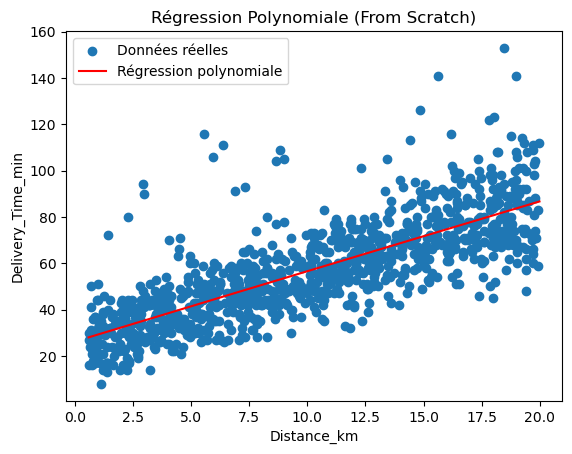

MSE: 189.80017601570265


In [15]:
# La regression polynomiale from scratch

X_poly = np.c_[x, x**2]    #la creation des variables polynomiale
# Normalisation 
mean = np.mean(X_poly, axis=0) # la moyenne de chaque colonne
std = np.std(X_poly, axis=0)  # calcule de l'écart type 
std[std == 0] = 1    # evite la division par zero

X_poly = (X_poly - mean) / std  # calcule de la normalisation
m = len(y)
X_b = np.c_[np.ones((m,1)), X_poly]   # l'ajout d'une colonne de 1 a la matice x_polu
theta = np.zeros(X_b.shape[1])    # initialisation de theta
def J(theta, X, y):      # fonction cout
    return (1/(2*m)) * np.sum((X.dot(theta) - y)**2)
alpha = 0.01
iterations = 10000

for i in range(iterations):  # gradient descent
    y_pred = X_b.dot(theta)  # calcule les prédictions
    gradient = (1/m) * X_b.T.dot(y_pred - y)   # calcule la dericée de l'erreur
    theta = theta - alpha * gradient  # met à jour les parametres

    if i % 1000 == 0:   # affiche l’erreur pour voir si elle diminue
        print(f"Iteration {i}, J =", J(theta, X_b, y))

print("Theta =", theta)
# Trier les données selon x pour tracer une courbe lisse
x_array = x.flatten()
sorted_indices = np.argsort(x_array)   #donne les positions pour trier x
x_sorted = x_array[sorted_indices]  # trier x 
y_sorted = y[sorted_indices]   #trier y de la même façon

X_poly_sorted = np.c_[x_sorted, x_sorted**2]  #recréer X_poly trié
X_poly_sorted = (X_poly_sorted - mean) / std  # normaliser avec les mêmes paramètre
X_b_sorted = np.c_[np.ones((m,1)), X_poly_sorted]   # Ajouter une colonne de 1 (biais) aux données triées
y_pred_sorted = X_b_sorted.dot(theta) #calcule de la prédiction

plt.scatter(x, y, label="Données réelles")
plt.plot(x_sorted, y_pred_sorted, color='red', label="Régression polynomiale")

plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.title("Régression Polynomiale (From Scratch)")
plt.legend()
plt.show()

y_pred = X_b.dot(theta)  # prédictions sur toutes les données

# MSE : moyenne des carrés des erreurs
mse = np.mean((y - y_pred)**2)
print("MSE:", mse)



Iteration 0, J = 94.90008355669357
Iteration 1000, J = 94.89670241187682
Iteration 2000, J = 94.89480360613763
Iteration 3000, J = 94.89373726221255
Iteration 4000, J = 94.89313841771623
Iteration 5000, J = 94.89280211465078
Iteration 6000, J = 94.89261325134403
Iteration 7000, J = 94.89250718823514
Iteration 8000, J = 94.89244762461077
Iteration 9000, J = 94.8924141744754


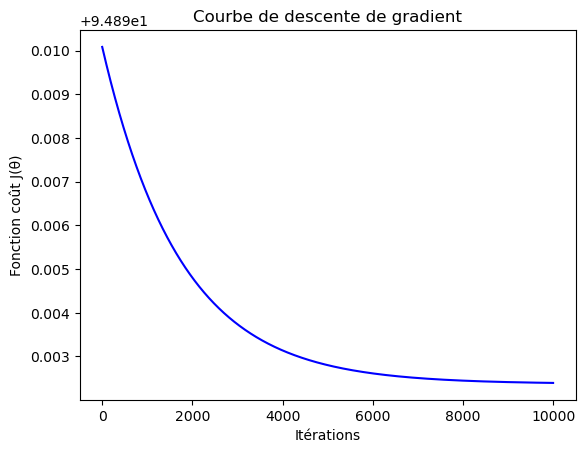

In [16]:
# Tracé de la convergence de la descente de gradient (évolution de J(θ))

J_history = []  # liste pour stocker le coût

for i in range(iterations):
    y_pred = X_b.dot(theta)
    gradient = (1/m) * X_b.T.dot(y_pred - y)
    theta = theta - alpha * gradient
    J_history.append((1/(2*m)) * np.sum((X_b.dot(theta) - y)**2))  # stocker J
    
    if i % 1000 == 0:
        print(f"Iteration {i}, J =", J_history[-1])

# Tracer la courbe de descente
import matplotlib.pyplot as plt
plt.plot(range(iterations), J_history, color='blue')
plt.xlabel("Itérations")
plt.ylabel("Fonction coût J(θ)")
plt.title("Courbe de descente de gradient")
plt.show()

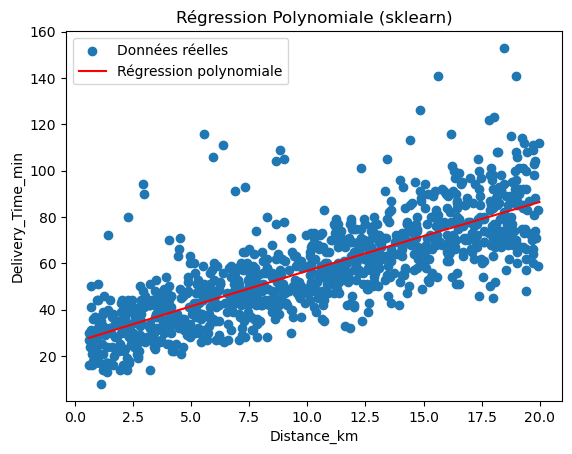

MSE: 189.78474265289114


In [17]:
#la regression polynomiale sklearn

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
import pandas as pd

x = data[['Distance_km']]  
y = data['Delivery_Time_min']

poly = PolynomialFeatures(degree=2)  # Création des variables polynomiales de degré 2
X_poly = poly.fit_transform(x)    # Transformation polynomiale (ajoute 1, x, x²)

scaler = StandardScaler()   #normalisation de données
X_poly_scaled = scaler.fit_transform(X_poly)  # calcule la moyenne et l’écart-type de X_poly
model = LinearRegression()    #crée un modèle de régression
model.fit(X_poly_scaled, y)   # Le modèle cherche les meilleurs theta pour minimiser l’erreur

y_pred = model.predict(X_poly_scaled) #prédictions sur les données

x_sorted_df = pd.DataFrame(x_sorted, columns=['Distance_km']) # trier pour une courbe propre tel que fltten() transforme en 1D

X_poly_sorted = poly.transform(x_sorted_df)  # transforme x trié en format 2D puis génère les variables polynomiales (x, x**2, ...)
X_poly_sorted = scaler.transform(X_poly_sorted)   #applique la normalisation

y_pred_sorted = model.predict(X_poly_sorted)    #prédictions correspondantes aux x triés

#Visualisation
plt.scatter(x, y, label="Données réelles")
plt.plot(x_sorted, y_pred_sorted, color='red', label="Régression polynomiale")

plt.xlabel("Distance_km")
plt.ylabel("Delivery_Time_min")
plt.title("Régression Polynomiale (sklearn)")
plt.legend()
plt.show()

# Calcul de MSE (Mean Squared Error)
mse = mean_squared_error(y, y_pred)
print("MSE:", mse)
